In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import numpy as np
from scipy.stats import multivariate_normal

def sample_gaussian_mixture(weights, means, covariances, n_samples):
    """
    Samples data points from a Gaussian Mixture Model.
    
    Args:
        weights (list): Mixing weights for the Gaussian components. Should sum to 1.
        means (list): List of mean vectors for each component.
        covariances (list): List of covariance matrices for each component.
        n_samples (int): Number of samples to generate.
    
    Returns:
        np.ndarray: Samples from the GMM, shape (n_samples, n_features).
        np.ndarray: Labels indicating the component of each sample, shape (n_samples,).
    """
    assert len(weights) == len(means) == len(covariances), "All inputs must have the same length"
    assert np.isclose(sum(weights), 1), "Weights must sum to 1"
    
    n_components = len(weights)
    n_features = len(means[0])
    
    # Determine the component each sample belongs to
    component_choices = np.random.choice(range(n_components), size=n_samples, p=weights)
    
    samples = np.zeros((n_samples, n_features))
    labels = np.zeros(n_samples, dtype=int)
    
    for i, component in enumerate(component_choices):
        samples[i] = np.random.multivariate_normal(mean=means[component], cov=covariances[component])
        labels[i] = component
    
    return samples, labels

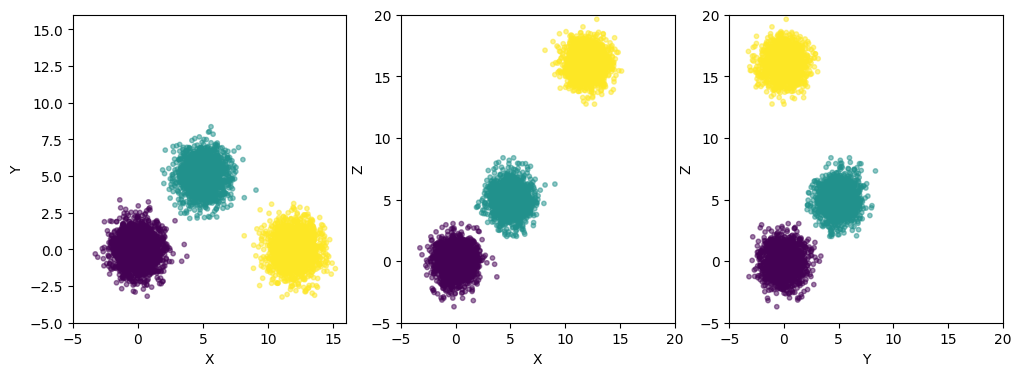

In [16]:
# Example usage
weights = [1/3, 1/3, 1/3]  # Mixture weights
means = [[0, 0, 0], [5, 5, 5], [12, 0, 16]]  # Means of the components
covariances = [np.eye(3), np.eye(3), np.eye(3)]  # Covariance matrices
n_samples = 5000  # Number of samples to generate

samples, labels = sample_gaussian_mixture(weights, means, covariances, n_samples)

# Plot the samples (optional)
fig, ax = plt.subplots(1,3,figsize=(12,4))

ax[0].scatter(samples[:, 0], samples[:, 1], c=labels, cmap='viridis', s=10, alpha=0.5)
ax[1].scatter(samples[:, 0], samples[:, 2], c=labels, cmap='viridis', s=10, alpha=0.5)
ax[2].scatter(samples[:, 1], samples[:, 2], c=labels, cmap='viridis', s=10, alpha=0.5)

ax[0].set(xlabel='X', ylabel='Y', xlim=[-5,16], ylim=[-5,16])
ax[1].set(xlabel='X', ylabel='Z', xlim=[-5,20], ylim=[-5,20])
ax[2].set(xlabel='Y', ylabel='Z', xlim=[-5,20], ylim=[-5,20])
plt.show()

In [18]:
samples.shape

(5000, 3)

In [17]:
25 + 25 + 11 * 11

171